In [1]:
# Bu Python 3 ortamında kullanışlı birçok analiz kütüphanesi yüklü geliyor
# Kaggle/python docker imajı ile hazırlanmış
# Örnek olarak bazı faydalı paketleri yüklüyorum

import numpy as np # lineer cebir
import pandas as pd # veri işleme, CSV dosya girdi/çıktısı (ör. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# import warnings
import warnings
# Uyarıları kapat
warnings.filterwarnings("ignore")
from subprocess import check_output
print(check_output(["ls", "../_02_KNN"]).decode("utf8"))

# Oluşturduğum sonuçlar mevcut dizinde çıktı olarak kaydedilir.

column_2C_weka.csv
column_3C_weka.csv
machine-learning-tutorial-for-beginners.ipynb



In [2]:
# read csv (comma separated value) into data
data = pd.read_csv('../_02_KNN/column_2C_weka.csv')
print(plt.style.available) # look at available plot styles
plt.style.use('ggplot')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


<a id="1"></a> <br>
#  MAKİNE ÖĞRENMESİ (ML)
Python içinde sklearn, keras ya da tensorflow gibi bazı ML kütüphaneleri var. Ben sklearn kullanacağım.


<a id="2"></a> <br>
## A. DENETİMLİ ÖĞRENME
* Denetimli öğrenme: Etiketli verilerle çalışır. Mesela ortopedik hasta verisinde *normal* ve *anormal* etiketleri vardır.
    * Özellikler (predictor variable) ve hedef değişken vardır. Özellikler *pelvic radius* veya *sacral slope* gibi şeylerdir. Bunlar ne diye bakmak isterseniz Google'dan görüntülere bakabilirsiniz; ben de öyle yapmıştım :) Hedef değişken ise *normal* ve *anormal* etiketleridir.
    * Amaç, özelliklerden yola çıkarak hedef değişkenin *normal* mi *anormal* mi olduğunu tahmin etmektir.
    * Sınıflandırma: hedef değişken normal/anormal gibi kategorilerden oluşur.
    * Regresyon: hedef değişken hisse fiyatı gibi sürekli bir değerdir.
    * Bu açıklamalar yetmediyse Google'a bakabilirsiniz. Yalnız terimleri karıştırmamak lazım: features = predictor variable = independent variable = columns = inputs. target variable = response variable = class = dependent variable = output = result

<a id="3"></a> <br>
### KEŞİFSEL VERİ ANALİZİ (EDA)
* Bir veriyle bir şey yapabilmek için önce veriyi tanımak gerekiyor. 
* Ben hep *head()* ile başlarım; burada özelliklerin *pelvic_incidence, pelvic_tilt numeric, lumbar_lordosis_angle, sacral_slope, pelvic_radius* ve *degree_spondylolisthesis* olduğunu, hedef değişkenin de *class* olduğunu görüyoruz.
* head(): varsayılan olarak ilk 5 satırı gösterir. Mesela 100 satır görmek isterseniz head(100) yazabilirsiniz.


In [3]:
# to see features and target variable
data.head()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [4]:
# En temel kontrol: eksik değer var mı, veri uzunluğu ne; önce info'ya bakalım
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


Gördüğünüz gibi:
* uzunluk: 310 (range index)
* Özellikler float tipinde
* Hedef değişkenler object, yani string gibi
* Tamam, veriye dair bir fikrimiz oluştu ama biraz daha içine bakalım
    * describe(): bunu önceki notta anlatmıştım, o yüzden burada kısa geçiyorum :)
        * Neden mean, std, max, min gibi istatistiklere bakıyoruz? Kısa cevap: görselleştirme yaparken değerlerin birbirine çok uzak olmaması işimizi kolaylaştırıyor. Burada değerler fena durmuyor; en azından bir özelliğin ortalaması 0.1 iken diğerinin 1000 olması gibi uyumsuz bir durum yok. Zaten biraz sonra bunun başka sebeplerini de göreceğiz.

In [5]:
data.describe()

,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


pd.plotting.scatter_matrix:
* yeşil: *normal* ve kırmızı: *anormal*
* c: renk
* figsize: figür boyutu
* diagonal: her özelliğin histogramı
* alpha: saydamlık
* s: işaretçi boyutu
* marker: işaretçi tipi 

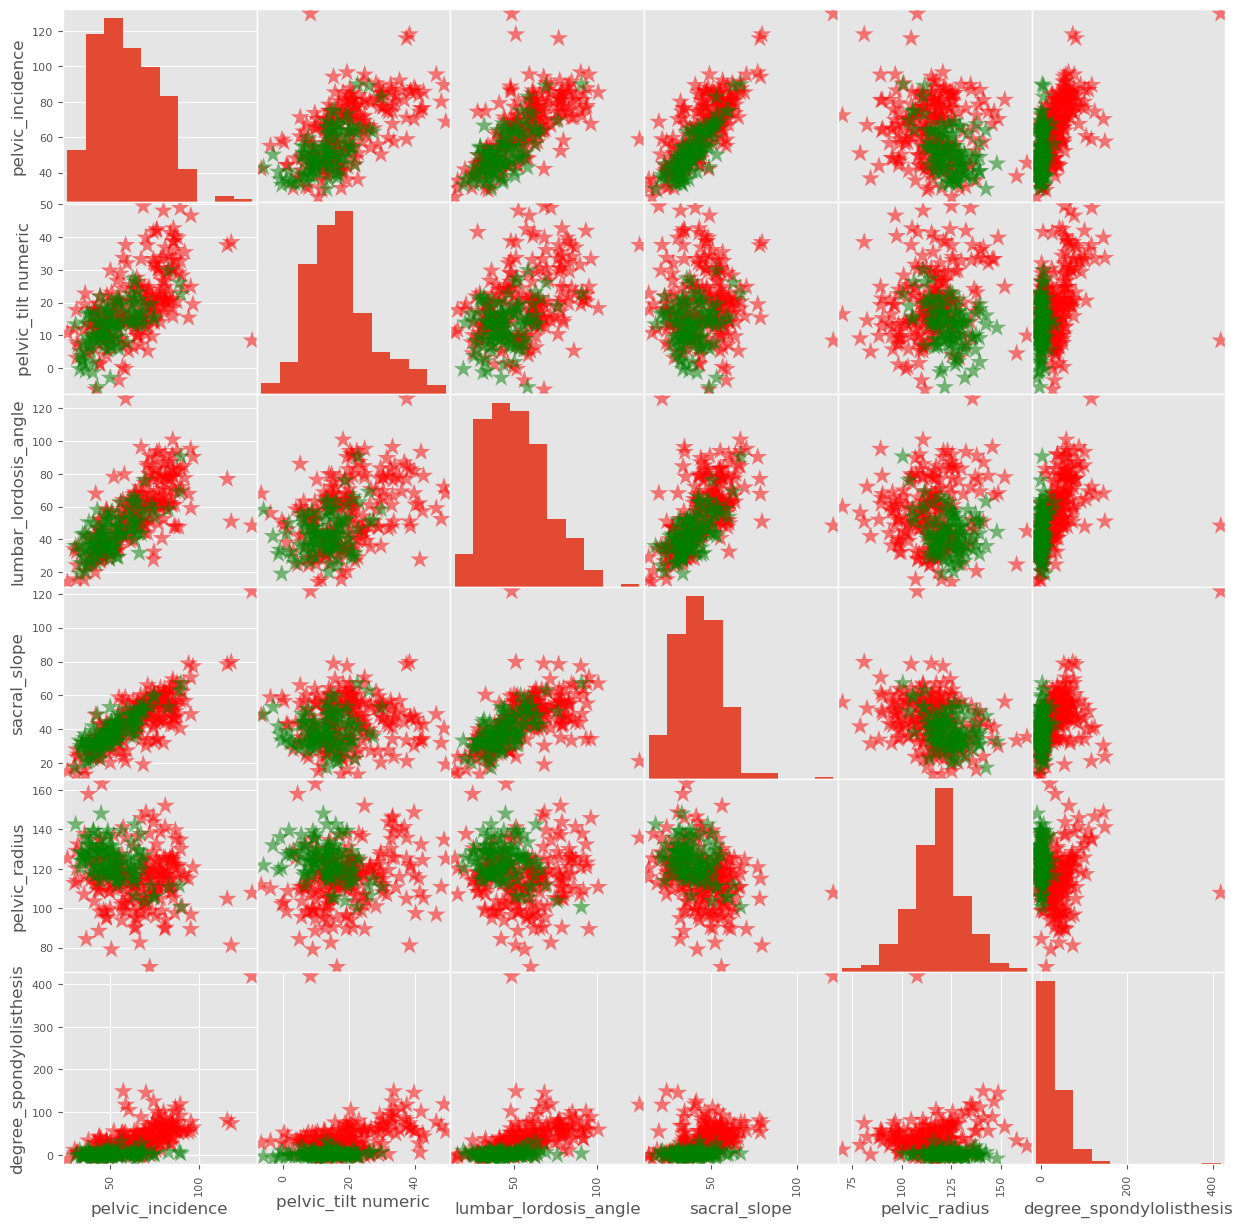

In [7]:
color_list = ['red' if i=='Abnormal' else 'green' for i in data.loc[:,'class']]
pd.plotting.scatter_matrix(data.loc[:, data.columns != 'class'],
                                       c=color_list,
                                       figsize= [15,15],
                                       diagonal='hist',
                                       alpha=0.5,
                                       s = 200,
                                       marker = '*')
plt.show()


Tamam, scatter matrix'ten özellikler arasındaki ilişkiyi gördük; peki *normal(yeşil)* ve *anormal(kırmızı)* sınıflar kaç tane? 
* Searborn kütüphanesinde sınıf sayısını saymak için *countplot()* var.
* İsterseniz *value_counts()* ile de yazdırabilirsiniz.

<br> Bu veri bana dengeli gibi geliyor. Aslında dengeli veri için kesin bir sayı yok ama bu veri bizim için yeterince dengeli.
<br> Şimdi ilk sınıflandırma yöntemi olan KNN'e geçelim.

class
Abnormal    210
Normal      100
Name: count, dtype: int64

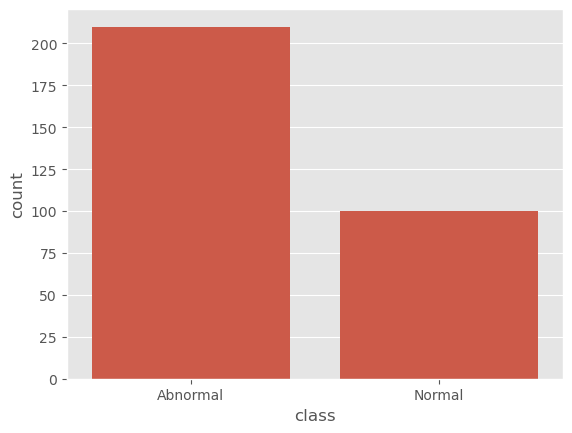

In [8]:
sns.countplot(x="class", data=data)
data.loc[:,'class'].value_counts()

<a id="4"></a> <br>
### K-EN YAKIN KOMŞU (KNN)
* KNN: K tane en yakın etiketli veri noktasına bakar.
* Bir sınıflandırma yöntemidir.
* Önce veriyi eğitmemiz gerekiyor. Train = fit.
* fit(): veriyi uydurur, modeli eğitir.
* predict(): tahmin yapar..
* x: özellikler
* y: hedef değişkenler (normal, abnormal)
* n_neighbors: K. Bu örnekte 3. Yani en yakın 3 etiketli veri noktasına bakılıyor.


In [9]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
x,y = data.loc[:,data.columns != 'class'], data.loc[:,'class']
knn.fit(x,y)
prediction = knn.predict(x)
print('Prediction: {}'.format(prediction))

Prediction: ['Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Normal' 'Normal'
 'Abnormal' 'Normal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Normal' 'Normal' 'Normal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Normal' 'Abnormal' 'Normal'
 'Normal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Normal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal' 'Abnormal'
 'Abnormal' 'Abnormal' 'Abnormal' 'Ab

* Tamam, veriyi fit ettik ve KNN ile tahmin yaptık.
* Peki doğru tahmin ediyor mu? Doğruluk oranımız ne, doğruluk en iyi ölçüt mü? Bunların cevabına bakalım.
<br> Model performansını ölçmek:
* Doğru tahminlerin oranı olan accuracy en sık kullanılan ölçütlerden biri. Şimdilik bunu kullanacağız ama başka bir sorun var.

<br>Gördüğünüz gibi veriyi x (özellikler) ile eğitip yine x üzerinden tahmin yapıyorum. Evet doğru okuyorsunuz ama bunun pek mantıklı olmadığını da siz fark etmişsinizdir :)

<br>Bu yüzden veriyi train ve test diye ayırmamız gerekiyor.
* train: eğitim seti, modeli bununla fit ederiz.
* test: tahmini bunun üzerinde yaparız.
* Train ve test ayrımı sayesinde eğitim ve değerlendirme birbirinden farklı olur.
* train_test_split(x,y,test_size = 0.3,random_state = 1)
    * x: özellikler
    * y: hedef değişkenler (normal, abnormal)
    * test_size: test oranı. Mesela test_size = 0.3 ise test %30, train %70 olur.
    * random_state: seed belirler. Aynı sayı verilirse train_test_split() her seferinde aynı bölmeyi üretir.
* fit(x_train,y_train): eğitim seti üzerinde modeli uydurur.
* score(x_test,y_test)): test setinde tahmin yapar ve accuracy verir.

In [10]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 1)
knn = KNeighborsClassifier(n_neighbors = 3)
x,y = data.loc[:,data.columns != 'class'], data.loc[:,'class']
knn.fit(x_train,y_train)
prediction = knn.predict(x_test)
#print('Prediction: {}'.format(prediction))
print('With KNN (K=3) accuracy is: ',knn.score(x_test,y_test)) # accuracy

With KNN (K=3) accuracy is:  0.8602150537634409


Accuracy %86 çıktı, yani iyi mi? Açıkçası ben de çok emin değilim; notun sonunda tekrar bakacağız.
<br> Şimdi soru şu: neden K = 3 seçtik ya da hangi K değerini seçmeliyiz? Cevap model karmaşıklığında gizli.

<br> Model karmaşıklığı:
* K'nin genel adı hiperparametredir. Şimdilik K'nin bir hiperparametre olduğunu ve en iyi performansı veren değeri seçmemiz gerektiğini bilin.
* Literatür der ki K küçükse model karmaşık olur ve overfit'e gidebilir. Yani model train setini ezberler, test setinde iyi sonuç vermez.
* K büyükse model daha basit olur ve underfit'e gidebilir.
* Aşağıda K değerini 1'den 25'e kadar gezdirip her biri için accuracy hesaplıyorum. Grafikte de görebileceğiniz gibi K = 1 iken model train setini ezberliyor ve testte iyi sonuç vermiyor (overfit). K = 18 iken de model underfit'e kayıyor. Yani yine tek başına accuracy her şeyi anlatmıyor. Buna rağmen K = 18 civarında en iyi performans yaklaşık %88 ile geliyor.



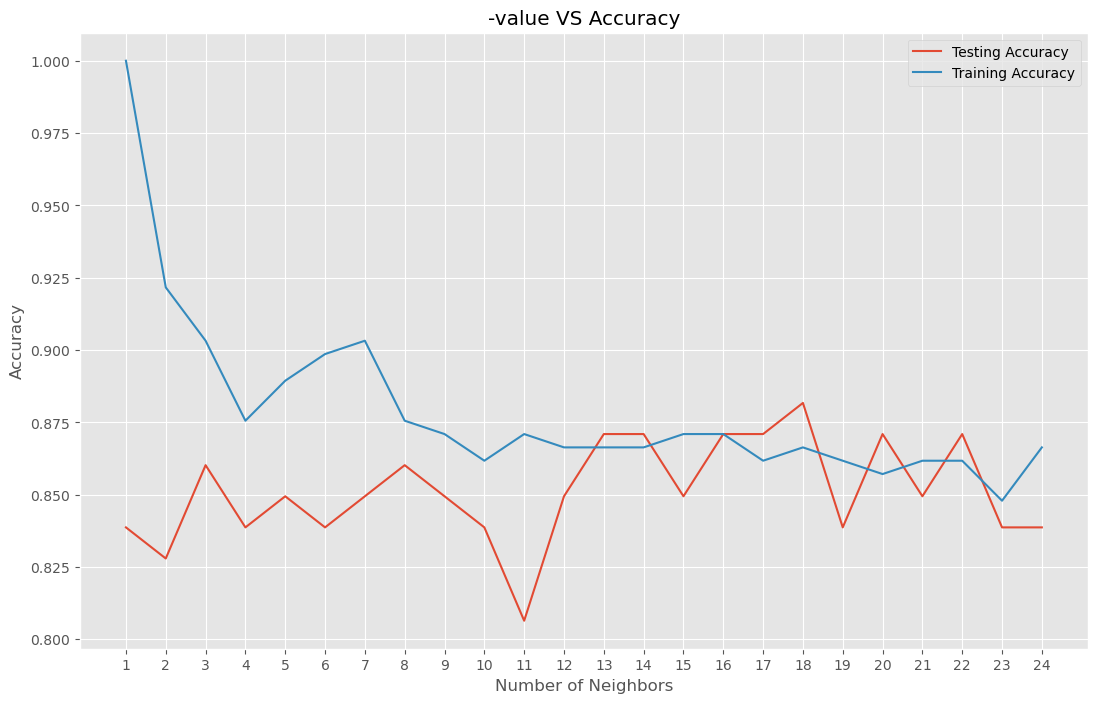

Best accuracy is 0.8817204301075269 with K = 18


In [11]:
# Model karmaşıklığı
neig = np.arange(1, 25)
train_accuracy = []
test_accuracy = []
# Farklı k değerlerini dolaş
for i, k in enumerate(neig):
    # k 1'den 25'e kadar
    knn = KNeighborsClassifier(n_neighbors=k)
    # KNN ile eğit
    knn.fit(x_train,y_train)
    # Eğitim doğruluğu
    train_accuracy.append(knn.score(x_train, y_train))
    # Test doğruluğu
    test_accuracy.append(knn.score(x_test, y_test))

# Çizim
plt.figure(figsize=[13,8])
plt.plot(neig, test_accuracy, label = 'Testing Accuracy')
plt.plot(neig, train_accuracy, label = 'Training Accuracy')
plt.legend()
plt.title('-value VS Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.xticks(neig)
plt.savefig('graph.png')
plt.show()
print("Best accuracy is {} with K = {}".format(np.max(test_accuracy),1+test_accuracy.index(np.max(test_accuracy))))

<a id="5"></a> <br>
### REGRESYON
* Denetimli öğrenme
* Lineer ve lojistik regresyonu öğreneceğiz.
* Bu ortopedik hasta verisi regresyon için çok uygun değil; bu yüzden yalnızca *sacral_slope* ve *pelvic_incidence* özelliklerini kullanıyorum. 
    * Ben burada feature olarak pelvic_incidence, target olarak sacral_slope düşünüyorum.
    * Daha iyi anlamak için scatter plot'a bakalım.
    * reshape(-1,1): Bunu kullanmazsak x veya y'nin şekli (210,) olur ve sklearn'de kullanamayız. reshape(-1,1) ile şekil (210, 1) oluyor.

In [ ]:
# create data1 that includes pelvic_incidence that is feature and sacral_slope that is target variable
data1 = data[data['class'] =='Abnormal']
x = np.array(data1.loc[:,'pelvic_incidence']).reshape(-1,1)
y = np.array(data1.loc[:,'sacral_slope']).reshape(-1,1)
# Scatter
plt.figure(figsize=[10,10])
plt.scatter(x=x,y=y)
plt.xlabel('pelvic_incidence')
plt.ylabel('sacral_slope')
plt.show()

Şimdi regresyon yapmak için verimiz hazır. Regresyon problemlerinde hedef değişken; ev fiyatı ya da sacral_slope gibi sürekli değişen bir değişkendir. Şimdi bu noktalara bir doğru uyduralım.

<br> Doğrusal regresyon
* y = ax + b  burada y = target, x = feature ve a = model parametresi
* Model parametresini (a) minimum hata fonksiyonuna göre seçeriz; bu hata fonksiyonuna loss function denir.
* Doğrusal regresyonda loss function olarak Ordinary Least Square (OLS) kullanırız.
* OLS: artıkların toplamını alırız ama pozitif ve negatif artıklar birbirini götürebileceği için artıkların karelerini toplarız. Buna OLS denir.
* Score: R^2 yöntemini kullanır; kabaca ((y_pred - y_mean)^2 )/(y_actual - y_mean)^2 gibi düşünebilirsiniz.

In [ ]:
# Doğrusal regresyon
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
# Tahmin aralığı
predict_space = np.linspace(min(x), max(x)).reshape(-1,1)
# Modeli eğit
reg.fit(x,y)
# Tahmin yap
predicted = reg.predict(predict_space)
# R^2 skoru
print('R^2 score: ',reg.score(x, y))
# Regresyon doğrusunu ve saçılımı çiz
plt.plot(predict_space, predicted, color='black', linewidth=3)
plt.scatter(x=x,y=y)
plt.xlabel('pelvic_incidence')
plt.ylabel('sacral_slope')
plt.show()

<a id="6"></a> <br>
### ÇAPRAZ DOĞRULAMA
KNN kısmında train_test_split kullanmıştık ve random_state verirsek her seferinde aynı bölmeyi alıyorduk. Ama random_state kullanmazsak veri her seferinde farklı bölünür ve accuracy de bölmeye göre değişir. Yani model performansı train_test_split'e bağlı kalır. Mesela 5 kez split edip fit ve predict yaparsanız doğruluklar sırasıyla 0.89, 0.9, 0.91, 0.92 ve 0.93 olabilir. Peki 6. denemede ne çıkacak? Bunu önceden bilemem. Cross validation kullanırsam daha kabul edilebilir bir performans ölçebilirim.
<br> Çapraz Doğrulama (CV)
* K folds = K fold CV.
* Bu resmi bir düşünün; anlatımdan daha iyi açıklıyor :)
* K arttıkça hesaplama maliyeti artar.
* cross_val_score(reg,x,y,cv=5): Yukarıda tanımladığımız reg (linear regression) ile x ve y'yi kullanır, K=5 olduğu için 5 kez split/train/predict yapar.


In [ ]:
# CV
from sklearn.model_selection import cross_val_score
reg = LinearRegression()
k = 5
cv_result = cross_val_score(reg,x,y,cv=k) # uses R^2 as score 
print('CV Scores: ',cv_result)
print('CV scores average: ',np.sum(cv_result)/k)

### Düzenlileştirilmiş Regresyon
Doğrusal regresyonda parametreleri (katsayıları) loss function'ı küçülterek seçtiğimizi öğrenmiştik. Eğer doğrusal regresyon bir özelliğin çok önemli olduğunu düşünürse o özelliğe yüksek katsayı verebilir. Ama bu durum KNN'deki ezberleme gibi overfitting'e yol açabilir. Overfitting'i azaltmak için büyük katsayıları cezalandıran regularization kullanılır.

* Ridge regresyon: İlk regularization tekniği. L2 regularization diye de geçer.
    * Ridge regression loss function = OLS + alpha * sum(parameter^2)
    * alpha, fit ve predict için seçmemiz gereken bir parametredir. Alpha seçmek KNN'de K seçmeye benzer. Yani alpha da en iyi accuracy ve model karmaşıklığı için seçtiğimiz hiperparametredir. Bu işleme hiperparametre ayarlama denir.
    * Alpha sıfırsa ne olur? loss function = OLS olur, yani bu doğrusal regresyondur :)
    * Alpha küçükse overfitting olabilir.
    * Alpha büyükse underfitting olabilir. Ama küçük ve büyük tam olarak ne demek, onu problemden probleme değiştirebilir.
* Lasso regresyon: İkinci regularization tekniği. L1 regularization diye de bilinir.
    * Lasso regression loss function = OLS + alpha * sum(absolute_value(parameter))
    * Veride önemli özellikleri seçmek için kullanılabilir. Çünkü değeri sıfıra doğru küçülmeyen özellikler lasso tarafından seçilmiş olur.
    * Özellik seçimini göstermek için regresyon verimize yeni özellikler ekliyorum.
    
<br> Linear vs Ridge vs Lasso
İlk izlenim: Linear
Özellik seçimi: 1.Lasso 2.Ridge
Regresyon modeli: 1.Ridge 2.Lasso 3.Linear 



In [ ]:
# Ridge
from sklearn.linear_model import Ridge
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 2, test_size = 0.3)
ridge = Ridge(alpha = 0.1, normalize = True)
ridge.fit(x_train,y_train)
ridge_predict = ridge.predict(x_test)
print('Ridge score: ',ridge.score(x_test,y_test))

In [ ]:
# Lasso
from sklearn.linear_model import Lasso
x = np.array(data1.loc[:,['pelvic_incidence','pelvic_tilt numeric','lumbar_lordosis_angle','pelvic_radius']])
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state = 3, test_size = 0.3)
lasso = Lasso(alpha = 0.1, normalize = True)
lasso.fit(x_train,y_train)
ridge_predict = lasso.predict(x_test)
print('Lasso score: ',lasso.score(x_test,y_test))
print('Lasso coefficients: ',lasso.coef_)

Gördüğünüz gibi *pelvic_incidence* ve *pelvic_tilt numeric* önemli özellikler, diğerleri ise pek önemli değil.

<br> Şimdi accuracy konusunu konuşalım. Model seçimi için tek başına yeterli mi? Mesela verinin %95'i normal, %5'i abnormal olsun ve modelimiz ölçüm için accuracy kullansın. Böyle bir durumda model tüm örnekleri normal tahmin ederse accuracy %95 olur ama abnormal örneklerin hepsini yanlış sınıflandırır. O yüzden dengesiz veride model ölçümü için confusion matrix kullanmamız gerekiyor.
<br> Confusion matrix kullanırken farklı bir sınıflandırma yöntemi olsun diye Random Forest classifier kullanalım.
* tp = true positive(20), fp = false positive(7), fn = false negative(8), tn = true negative(58) 
* tp = Tahmin pozitif(normal) ve gerçek pozitif(normal). 
* fp = Tahmin pozitif(normal) ve gerçek negatif(abnormal).
* fn = Tahmin negatif(abnormal) ve gerçek pozitif(normal).
* tn = Tahmin negatif(abnormal) ve gerçek negatif(abnormal).
* precision = tp / (tp+fp)
* recall = tp / (tp+fn)
* f1 = 2 * precision * recall / ( precision + recall)



In [ ]:
# Random Forest ile confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
x,y = data.loc[:,data.columns != 'class'], data.loc[:,'class']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 1)
rf = RandomForestClassifier(random_state = 4)
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
cm = confusion_matrix(y_test,y_pred)
print('Confusion matrix: \n',cm)
print('Classification report: \n',classification_report(y_test,y_pred))

In [ ]:
# visualize with seaborn library
sns.heatmap(cm,annot=True,fmt="d") 
plt.show()

<a id="7"></a> <br>
### Lojistik Regresyon ile ROC Eğrisi 
* Lojistik regresyonun çıktısı olasılıktır.
* Olasılık 0.5'ten büyükse veri 1 (anormal), değilse 0 (normal) olarak etiketlenir.
* Varsayılan olarak lojistik regresyonda eşik 0.5'tir.
* ROC, receiver operating characteristic demektir. Bu eğride x ekseni false positive rate, y ekseni true positive rate'tir.
* Eğri grafikte sol üst köşeye ne kadar yakınsa test o kadar başarılıdır.
* ROC eğrisi skoru olan auc, tahmin skorlarından eğri altındaki alanı ölçer.
* auc'nin 1'e yaklaşmasını isteriz.
* fpr = False Positive Rate
* tpr = True Positive Rate
* İsterseniz ROC, Random Forest ve K fold CV'yi anlattığım başka bir not da var: https://www.kaggle.com/kanncaa1/roc-curve-with-k-fold-cv/

In [ ]:
# Lojistik regresyon ile ROC eğrisi
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
# abnormal = 1 ve normal = 0
data['class_binary'] = [1 if i == 'Abnormal' else 0 for i in data.loc[:,'class']]
x,y = data.loc[:,(data.columns != 'class') & (data.columns != 'class_binary')], data.loc[:,'class_binary']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)
logreg = LogisticRegression()
logreg.fit(x_train,y_train)
y_pred_prob = logreg.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
# ROC eğrisini çiz
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()



<a id="8"></a> <br>
### HİPERPARAMETRE AYARLAMA
KNN kısmında söylediğim gibi ayarlanması gereken hiperparametreler var.
* Mesela:
    * KNN'de k
    * Ridge ve Lasso'da alpha
    * Random Forest parametreleri, mesela max_depth
    * Doğrusal regresyon parametreleri (katsayılar)
* Hiperparametre ayarlama:
    * farklı parametrelerin tüm kombinasyonlarını dene
    * hepsini fit et
    * tahmin performansını ölç
    * hangisinin nasıl çalıştığına bak
    * sonunda en iyi hiperparametreleri seç
* Bu bölüm aslında notun en zor kısmı ama çok da korkulacak bir şey değil. Hepsini tek tek for döngüleriyle yapacağız diye düşünmeyin; şaka yapıyorum :) (Bunu KNN kısmında zaten yaptık.)
* Tek satırda GridSearchCV kullanacağız.
    * grid: K 1'den 50'ye kadar
    * GridSearchCV, knn ve grid'i alıp grid search yapar. Yani burada k için tüm kombinasyonları dener.


In [ ]:
# 1 hiperparametreli grid search ve çapraz doğrulama
from sklearn.model_selection import GridSearchCV
grid = {'n_neighbors': np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, grid, cv=3) # GridSearchCV
knn_cv.fit(x,y)# Eğit

# Hiperparametreyi yazdır
print("Tuned hyperparameter k: {}".format(knn_cv.best_params_)) 
print("Best score: {}".format(knn_cv.best_score_))


Başka bir grid search örneği, bu sefer 2 hiperparametre ile.
* İlk hiperparametre C: lojistik regresyonun regularization parametresi.
    * C büyükse: overfit
    * C küçükse: underfit
* İkinci hiperparametre penalty (loss function): lojistik regresyon kısmında öğrendiğimiz gibi l1 (Lasso) ya da l2 (Ridge).

In [ ]:
# 2 hiperparametreli grid search ve çapraz doğrulama
# 1. hiperparametre C: lojistik regresyonun regularization parametresi
# 2. hiperparametre penalty: l1 veya l2
# Hiperparametre ızgarası
param_grid = {'C': np.logspace(-3, 3, 7), 'penalty': ['l1', 'l2']}
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3,random_state = 12)
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg,param_grid,cv=3)
logreg_cv.fit(x_train,y_train)

# En uygun parametreleri ve en iyi skoru yazdır
print("Tuned hyperparameters : {}".format(logreg_cv.best_params_))
print("Best Accuracy: {}".format(logreg_cv.best_score_))


<a id="9"></a> <br>
### VERİ ÖN İŞLEME
* Gerçek hayatta veride object ya da kategorik sütunlar olabilir; bunları sklearn'de kullanmak için sayısal hale çevirmek gerekir.
* Veride class *abnormal* ve *normal*. Bunları sayısal değere çevirelim. (Aslında lojistik regresyon kısmında başka bir yöntemle bunu yaptım.)
* *class_Abnormal* ve *class_Normal* adında 2 ayrı özellik oluşuyor.
* Ama bunlardan birini silmek gerekiyor çünkü aynı bilgiyi tekrar ediyorlar.

In [ ]:
# Load data
data = pd.read_csv('../input/column_2C_weka.csv')
# get_dummies
df = pd.get_dummies(data)
df.head(10)

In [ ]:
# drop one of the feature
df.drop("class_Normal",axis = 1, inplace = True) 
df.head(10)
# instead of two steps we can make it with one step pd.get_dummies(data,drop_first = True)

Ön işleme adımlarından biri de merkezleme, ölçekleme ya da normalleştirme.
* Bana kulak verip KNN videosu izlediyseniz, KNN'nin sınıflandırmada mesafeye dayalı çalıştığını görmüşsünüzdür. O yüzden veriyi ölçeklemek gerekiyor. Bunun için:
    * standardization: ( x - x.mean ) / x.variance   ya da   (x - x.min) / x.range
* pipeline: amaç svm(classifier) ve standardization(pre-processing) gibi birkaç adımı bir araya getirmek.
* Parametre isimlerini nasıl yazıyoruz? Mesela SVM__C : stepName__parameterName
* Sonra en iyi parametreleri bulmak için grid search yapıyoruz.

In [ ]:
# SVM, pre-process and pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
steps = [('scalar', StandardScaler()),
         ('SVM', SVC())]
pipeline = Pipeline(steps)
parameters = {'SVM__C':[1, 10, 100],
              'SVM__gamma':[0.1, 0.01]}
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state = 1)
cv = GridSearchCV(pipeline,param_grid=parameters,cv=3)
cv.fit(x_train,y_train)

y_pred = cv.predict(x_test)

print("Accuracy: {}".format(cv.score(x_test, y_test)))
print("Tuned Model Parameters: {}".format(cv.best_params_))


<a id="10"></a> <br>
## DENETİMSİZ ÖĞRENME
* Denetimsiz öğrenme: etiketlenmemiş verilerle çalışır ve gizli örüntüleri ortaya çıkarmaya çalışır. Mesela ortopedik hasta verisinde etiket yoksa hangi hastanın normal hangi hastanın anormal olduğunu bilemezsiniz.
* Bildiğiniz gibi ortopedik hasta verisi etiketli (denetimli) bir veri. Yani hedef değişkenleri var. Denetimsiz öğrenme çalışmak için hedef değişkeni silelim ve sadece *pelvic_radius* ile *degree_spondylolisthesis* üzerinden bakalım.


<a id="11"></a> <br>
### KMEANS
* İlk deneyeceğim denetimsiz yöntem KMeans kümeleme olacak.
* KMeans kümeleme: algoritma, verilen özelliklere göre her veri noktasını K gruptan birine atamak için iteratif çalışır. Veri noktaları özellik benzerliğine göre kümelenir.
* KMeans(n_clusters = 2): n_clusters = 2 demek 2 küme oluştur demektir.

In [ ]:
# Veride etiket yokmuş gibi gösteriyoruz
data = pd.read_csv('../input/column_2C_weka.csv')
plt.scatter(data['pelvic_radius'],data['degree_spondylolisthesis'])
plt.xlabel('pelvic_radius')
plt.ylabel('degree_spondylolisthesis')
plt.show()

In [ ]:
# KMeans kümeleme
data2 = data.loc[:,['degree_spondylolisthesis','pelvic_radius']]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 2)
kmeans.fit(data2)
labels = kmeans.predict(data2)
plt.scatter(data['pelvic_radius'],data['degree_spondylolisthesis'],c = labels)
plt.xlabel('pelvic_radius')
plt.xlabel('degree_spondylolisthesis')
plt.show()

<a id="12"></a> <br>
### KÜMELEMENİN DEĞERLENDİRİLMESİ
Veriyi iki gruba ayırdık. Peki bu doğru bir kümeleme mi? Bunu değerlendirmek için cross tabulation tablosu kullanacağız.
* İki küme var: *0* ve *1*
* İlk sınıf *0* içinde 138 anormal ve 100 normal hasta var.
* İkinci sınıf *1* içinde 72 anormal ve 0 normal hasta var.
* İki kümenin de çoğunluğu anormal hasta gibi görünüyor.

In [ ]:
# cross tabulation table
df = pd.DataFrame({'labels':labels,"class":data['class']})
ct = pd.crosstab(df['labels'],df['class'])
print(ct)

Yeni soru şu: veri içinde kaç sınıf olduğunu biliyoruz ama ya sayıyı bilmiyorsak? Bu da KNN ya da regresyondaki hiperparametre fikrine benziyor.
* inertia: kümelerin ne kadar yayıldığını, her örneğe olan uzaklık üzerinden ölçer.
* inertia düştükçe daha fazla küme oluşmuş olur.
* En iyi küme sayısı nedir?
    * Düşük inertia ile gereğinden fazla küme arasında bir denge kurup elbow yöntemini seçebiliriz.

In [ ]:
# inertia
inertia_list = np.empty(8)
for i in range(1,8):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data2)
    inertia_list[i] = kmeans.inertia_
plt.plot(range(0,8),inertia_list,'-o')
plt.xlabel('Number of cluster')
plt.ylabel('Inertia')
plt.show()

<a id="13"></a> <br>
### STANDARTLAŞTIRMA
* Standardizasyon hem denetimli hem denetimsiz öğrenme için önemli.
* Ön işleme adımı olarak standardizasyonu atlamamak lazım.
* Veriyi zaten görselleştirdiğimiz için fikri gördünüz. Şimdi kümeleme için tüm özellikleri kullanabiliriz.
* Denetimli öğrenmede olduğu gibi pipeline kullanılabilir.

In [ ]:
data = pd.read_csv('../input/column_2C_weka.csv')
data3 = data.drop('class',axis = 1)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
scalar = StandardScaler()
kmeans = KMeans(n_clusters = 2)
pipe = make_pipeline(scalar,kmeans)
pipe.fit(data3)
labels = pipe.predict(data3)
df = pd.DataFrame({'labels':labels,"class":data['class']})
ct = pd.crosstab(df['labels'],df['class'])
print(ct)

<a id="14"></a> <br>
### HİYERARŞİ
* Dikey çizgiler kümeleri gösterir.
* Dendrogramdaki yükseklik: birleşen kümeler arasındaki mesafe.
* method='single': kümelerin en yakın noktalarını kullanır.

In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram

merg = linkage(data3.iloc[200:220,:],method = 'single')
dendrogram(merg, leaf_rotation = 90, leaf_font_size = 6)
plt.show()

<a id="15"></a> <br>
### T - Dağıtılmış Stokastik Komşu Gömme (T - SNE)
 * learning rate: normalde 50-200 arası kullanılır
 * fit_transform: hem fit hem transform yapar. t-sne'de sadece fit_transform vardır
 * Aynı sınıftakiler birbirine yakın görünür

In [ ]:
from sklearn.manifold import TSNE
model = TSNE(learning_rate=100)
transformed = model.fit_transform(data2)
x = transformed[:,0]
y = transformed[:,1]
plt.scatter(x,y,c = color_list )
plt.xlabel('pelvic_radius')
plt.xlabel('degree_spondylolisthesis')
plt.show()

<a id="16"></a> <br>
### TEMEL BİLEŞEN ANALİZİ (PCA)
* Temel boyut azaltma tekniklerinden biridir.
* İlk adım decorrelation'dır:
    * veri örneklerini eksenlerle hizalanacak şekilde döndürür
    * veri örneklerini ortalaması sıfır olacak şekilde kaydırır
    * bilgi kaybolmaz
    * fit(): örnekleri nasıl kaydıracağını öğrenir
    * transform(): öğrenilen dönüşümü uygular. Test verisine de uygulanabilir.
* Ortaya çıkan PCA özellikleri doğrusal olarak korele değildir.
* Principal components: varyans yönleridir.

In [ ]:
# PCA
from sklearn.decomposition import PCA
model = PCA()
model.fit(data3)
transformed = model.transform(data3)
print('Principle components: ',model.components_)

In [ ]:
# PCA variance
scaler = StandardScaler()
pca = PCA()
pipeline = make_pipeline(scaler,pca)
pipeline.fit(data3)

plt.bar(range(pca.n_components_), pca.explained_variance_)
plt.xlabel('PCA feature')
plt.ylabel('variance')
plt.show()


* Second step: intrinsic dimension: number of feature needed to approximate the data essential idea behind dimension reduction
* PCA identifies intrinsic dimension when samples have any number of features
* intrinsic dimension = number of PCA feature with significant variance
* In order to choose intrinsic dimension try all of them and find best accuracy
* Also check intuitive way of PCA with this example: https://www.kaggle.com/kanncaa1/tutorial-pca-intuition-and-image-completion

In [ ]:
# apply PCA
pca = PCA(n_components = 2)
pca.fit(data3)
transformed = pca.transform(data3)
x = transformed[:,0]
y = transformed[:,1]
plt.scatter(x,y,c = color_list)
plt.show()

# SONUÇ
Bu notların sonuna geldim. İlk bölüm şurada:
<br>  https://www.kaggle.com/kanncaa1/data-sciencetutorial-for-beginners/
<br>**Sorunuz ya da öneriniz olursa bakarım.**